# Task 1: Dimensionality Reduction on Hydrogen Tweets Dataset

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D 


Task 1: Prepare the dataset

In [8]:
# set random seed
random_seed = 42

In [9]:
# Load data
X = pd.read_csv("Datasets/tfidf_features.csv")

In [10]:
n_samples, n_dims = X.shape
print(f"TF-IDF matrix shape: {n_samples:,} samples × {n_dims:,} dimensions")

TF-IDF matrix shape: 2,500 samples × 8,968 dimensions


In [11]:
# Connect labels
labels = pd.read_csv("Datasets/hydrogen.csv")
y = labels["label"].values

In [12]:
# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

Task 2: The curse of high dimensionality

In [13]:
dims = [2, 5, 10, 20, 50, 100, 200, 300, 500, 800, 1000, 1500, 2000, 3000, 5000, n_dims]

In [14]:
# Shuffle the features randomly to avoid bias for first features
rng = np.random.default_rng(random_seed)
perm = rng.permutation(n_dims)
X_perm = X[:, perm]

In [15]:
nearest_means   = []
tenth_means     = []
furthest_means  = []

for d in dims:
    Xd = X_perm[:, :d]
    D = pairwise_distances(Xd, metric="euclidean", n_jobs=-1)

    # Nearest neighbor
    np.fill_diagonal(D, np.inf)
    nearest = D.min(axis=1)

    # Distance to neighbor #10
    tenth = np.partition(D, kth=9, axis=1)[:, 9]

    # Furthest neighbor
    np.fill_diagonal(D, -np.inf)
    furthest = D.max(axis=1)

    nearest_means.append(float(nearest.mean()))
    tenth_means.append(float(tenth.mean()))
    furthest_means.append(float(furthest.mean()))

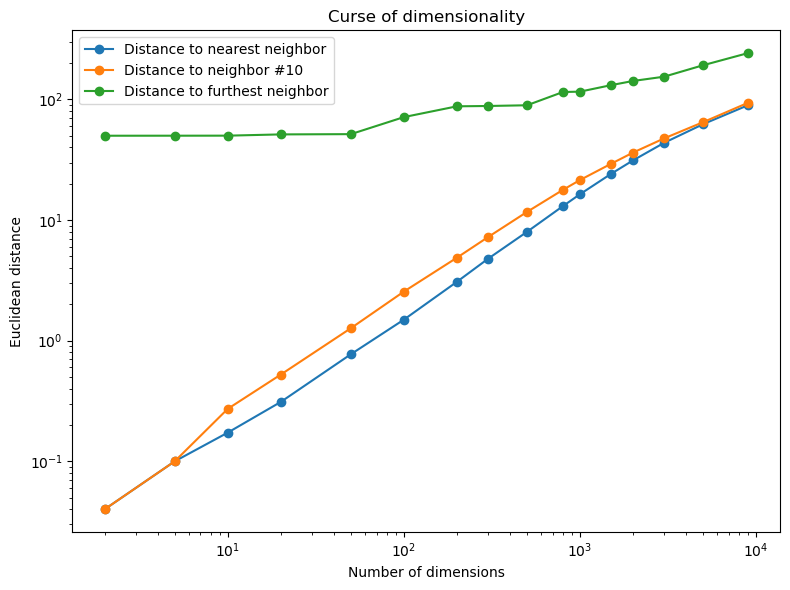

In [16]:
# Plot
plt.figure(figsize=(8,6))
plt.xscale("log"); plt.yscale("log")

plt.plot(dims, nearest_means,  "-o", label="Distance to nearest neighbor")
plt.plot(dims, tenth_means,    "-o", label="Distance to neighbor #10")
plt.plot(dims, furthest_means, "-o", label="Distance to furthest neighbor")

plt.xlabel("Number of dimensions")
plt.ylabel("Euclidean distance")
plt.title("Curse of dimensionality")
plt.legend()
plt.tight_layout()
plt.savefig("Outputs/curse_of_dimensionality.png", dpi=180)
plt.show()

Task 3: PCA

In [17]:
# Method: cumulative explained variance
comps_num = np.arange(1, n_samples+1, 100)
comps_variance = []

for k in comps_num:
    pca = PCA(n_components=k, random_state=random_seed)
    pca.fit(X)

    total_explained_variance = sum(pca.explained_variance_ratio_)
    comps_variance.append(total_explained_variance)


Following the Tutorial the optimal number of components is reached at 80-95%. We take the lowest threshold (80%) here as it already takes this many components.

In [22]:
# We did a finer analysis before where we got the result k80 = 1330, but here we just used stepsize =100, so we get a different result
comps_variance = np.array(comps_variance)
k80_idx = np.where(comps_variance >= 0.80)[0][0]
k80 = int(comps_num[k80_idx])
print(f"Smallest k for 80% variance: {k80}")

Smallest k for 80% variance: 1401


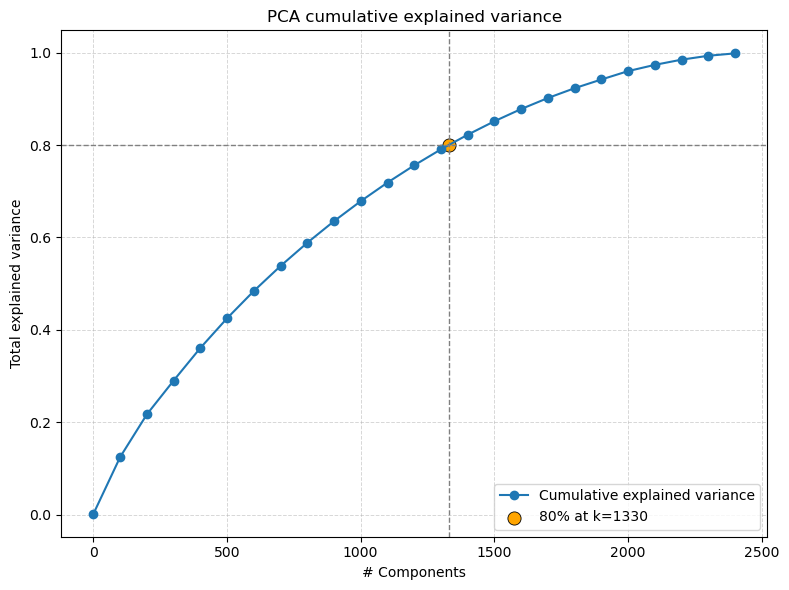

In [23]:
# Plot
k80 = 1330 # Set k80 to the optimal value from before
plt.figure(1, figsize=(8, 6))
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.5)
plt.plot(comps_num, comps_variance, marker='o', label="Cumulative explained variance")
plt.xlabel("# Components")
plt.ylabel("Total explained variance")
plt.title("PCA cumulative explained variance")
plt.tight_layout()

# plot 80% threshold
plt.axhline(0.80, color='gray', ls='--', lw=1)
plt.axvline(k80,  color='gray', ls='--', lw=1)
plt.scatter([k80], [0.80], s=90, color='orange', edgecolor='k', linewidth=0.6, label=f"80% at k={k80}")

plt.legend(loc="lower right")
plt.savefig("Outputs/pca_elbow.png", dpi=180)
plt.show()

Method two: Cluster visualization (Drop it)
Doesn't make any sense since we can't plot more than three components at a time.


Explained variance ratio (Top 5 PCs):
  PC1: 0.0022
  PC2: 0.0022
  PC3: 0.0020
  PC4: 0.0020
  PC5: 0.0019
Total explained variance (Top 5): 0.0104


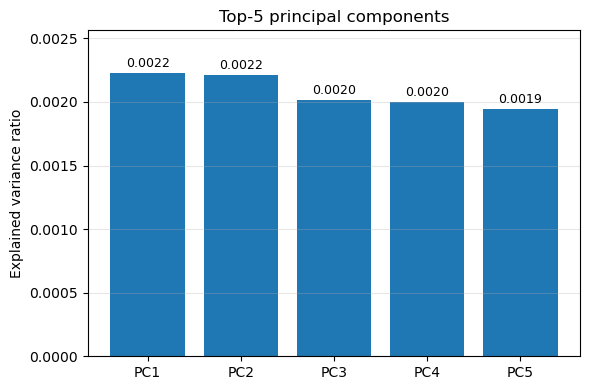

In [24]:
# Top five components
pca5 = PCA(n_components=5, random_state=random_seed).fit(X)
evr5 = pca5.explained_variance_ratio_

print("\nExplained variance ratio (Top 5 PCs):")
for i, v in enumerate(evr5, 1):
    print(f"  PC{i}: {v:.4f}")
print(f"Total explained variance (Top 5): {evr5.sum():.4f}")

Task 4: t-SNE

In [25]:
print(k80)

1330


In [26]:
X_pca = PCA(n_components=k80, random_state=random_seed).fit_transform(X) # PCA reduced dataset

# Reduce PCA reduced dataset to one, two and three components
kl_by_dim = {}
for d in [1, 2, 3]:
    tsne = TSNE(n_components=d, random_state=random_seed)
    X_tsne = tsne.fit_transform(X_pca)
    kl_by_dim[d] = float(tsne.kl_divergence_)

print("t-SNE KL divergence with default settings on PCA-reduced data:")
for d in [1, 2, 3]:
    print(f"  for {d} component(s): KL = {kl_by_dim[d]:.6f}")

t-SNE KL divergence with default settings on PCA-reduced data:
  for 1 component(s): KL = 3.444443
  for 2 component(s): KL = 2.693097
  for 3 component(s): KL = 2.902736


In [27]:
# As seen before 2 components is the best choice

# Determine optimal perplexity value
# Strategy: Try out all values between 5 and 50 as perplexity is between 5 and 50. (stepsize 5)

tsne_perplexity_num = np.arange(5, 50+1)
tsne_perplexity_divergence = []
for perplexity in tsne_perplexity_num:
    # Fit a TSNE model with 2 components.
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_seed)
    tsne.fit(X_pca)
    tsne_perplexity_divergence.append(tsne.kl_divergence_)
    print(f"KL Divergence for perplexity of {perplexity}: {tsne.kl_divergence_}")

KL Divergence for perplexity of 5: 2.782914161682129
KL Divergence for perplexity of 6: 2.863908290863037
KL Divergence for perplexity of 7: 2.9035348892211914
KL Divergence for perplexity of 8: 2.8891258239746094
KL Divergence for perplexity of 9: 2.9099035263061523
KL Divergence for perplexity of 10: 2.9210309982299805
KL Divergence for perplexity of 11: 2.9104526042938232
KL Divergence for perplexity of 12: 2.898746967315674
KL Divergence for perplexity of 13: 2.8930933475494385
KL Divergence for perplexity of 14: 2.8798627853393555
KL Divergence for perplexity of 15: 2.8865349292755127
KL Divergence for perplexity of 16: 2.885509967803955
KL Divergence for perplexity of 17: 2.8303630352020264
KL Divergence for perplexity of 18: 2.8436830043792725
KL Divergence for perplexity of 19: 2.8360538482666016
KL Divergence for perplexity of 20: 2.817758560180664
KL Divergence for perplexity of 21: 2.799206018447876
KL Divergence for perplexity of 22: 2.7703890800476074
KL Divergence for per

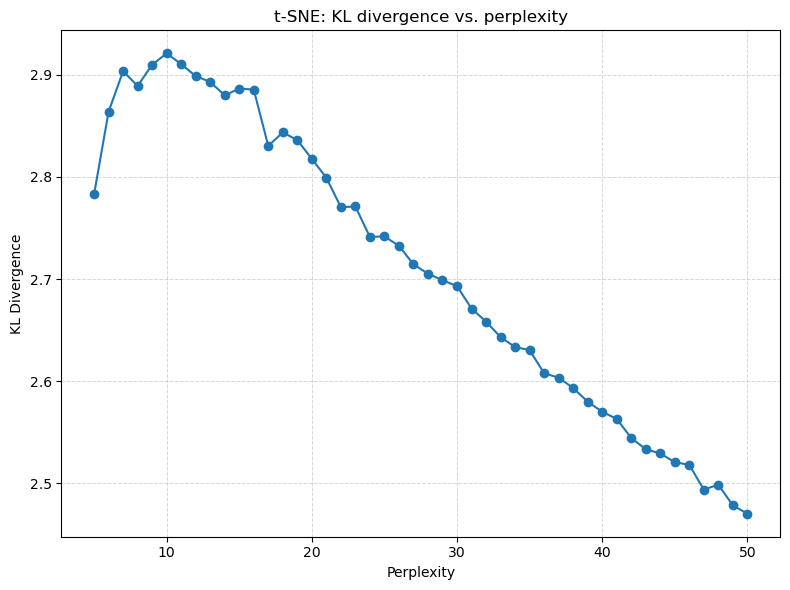

In [28]:
# Plot
plt.figure(1, figsize=(8, 6))
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.5)
plt.plot(tsne_perplexity_num, tsne_perplexity_divergence, marker='o')
plt.xlabel("Perplexity")
plt.ylabel("KL Divergence")
plt.title("t-SNE: KL divergence vs. perplexity")
plt.tight_layout()
plt.savefig("Outputs/t_sne_plot.png", dpi=180)
plt.show()

selected perplexity: 50 since it has the lowest KL divergence

Task 5: Comparative Visualisation

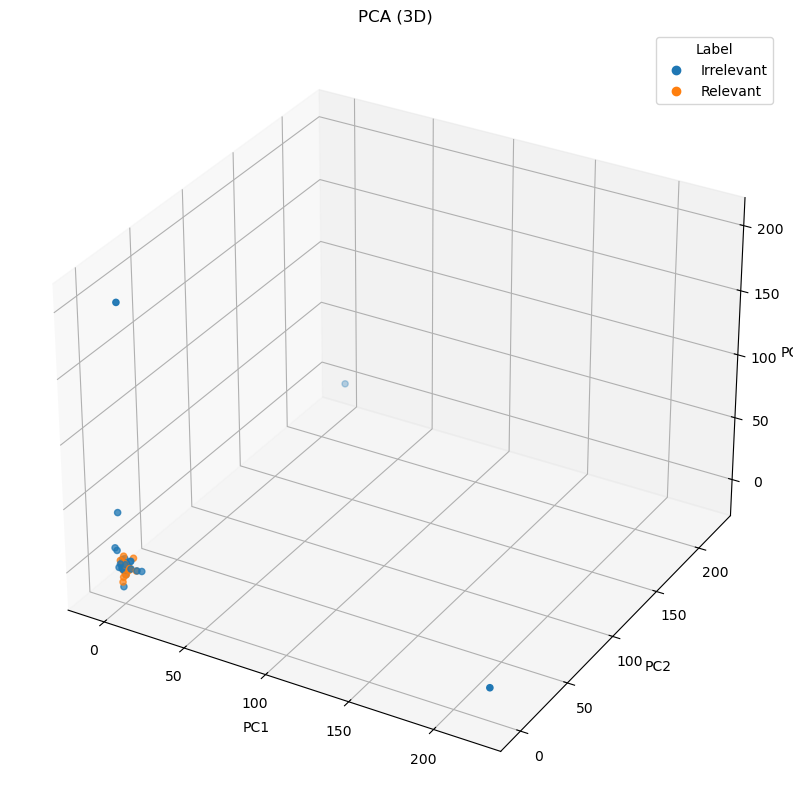

In [29]:
# Plot three Principal Components PCA
pca3 = PCA(n_components=3, random_state=random_seed).fit(X)
X_pca3 = pca3.transform(X)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

# Paint "Irrelevant" in blue and "Relevant" in orange
palette = {"Irrelevant":"tab:blue", "Relevant":"tab:orange"}
colors = [palette[v] for v in y]
scatter = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=colors, s=20)
ax.legend(handles=[Line2D([],[], marker='o', ls='', color=palette[k], label=k)
                   for k in palette], title="Label")

ax.set(xlabel="PC1", ylabel="PC2", zlabel="PC3")
plt.title("PCA (3D)")
plt.savefig("Outputs/PCA_three_PCs.png", dpi=180)
plt.show()

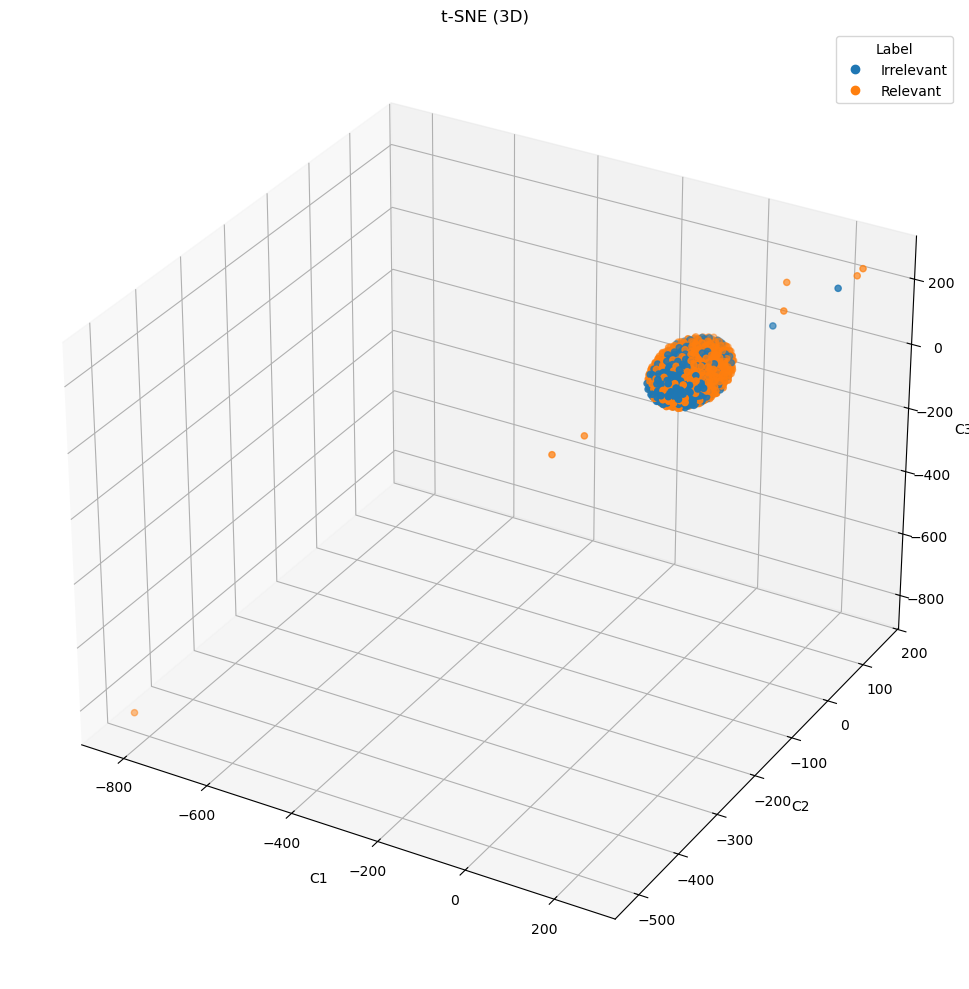

In [30]:
# Plot three Components for t-SNE
tsne3 = TSNE(n_components=3, perplexity=50, random_state=random_seed)
X_tsne3 = tsne3.fit_transform(X)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

# Paint "Irrelevant" in blue and "Relevant" in orange
palette = {"Irrelevant": "tab:blue", "Relevant": "tab:orange"}
colors = [palette[v] for v in y]

scatter = ax.scatter(X_tsne3[:, 0], X_tsne3[:, 1], X_tsne3[:, 2],
                     c=colors, s=20)
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=palette[k], label=k)
             for k in palette], title="Label")

ax.set(xlabel="C1", ylabel="C2", zlabel="C3")
plt.title("t-SNE (3D)")
plt.tight_layout()
plt.savefig("Outputs/TSNE_three_components.png", dpi=180)
plt.show()